In [ ]:
from bing_image_downloader import downloader

#downloader.download(query="뉴진스 혜린", limit=15, output_dir="./data/Celeb/", adult_filter_off=True, force_replace=False, timeout=30)
#downloader.download(query="카리나", limit=100, output_dir="./data/Celeb/", adult_filter_off=True, force_replace=False, timeout=30)
#downloader.download(query="장원영", limit=100, output_dir="./data/Celeb/", adult_filter_off=True, force_replace=False, timeout=30)

# Transfer Learning (전이학습)
* 연예인 분류하기

In [105]:
import os, shutil

def dataset_split(query, train_cnt):
    
    root_dir = ".\\data\\Celeb\\"
    
    directory_list = [
        os.path.join(root_dir, "train"),
        os.path.join(root_dir, "test")
    ]
    
    for dir in directory_list:
        if not os.path.isdir(os.path.join(dir, query)):     # ./data/Celeb/train/{celeb's name} 없으면 만듦
            os.makedirs(os.path.join(dir, query))
            print(os.path.join(dir, query))
    
    cnt = 0
    for file_name in os.listdir(os.path.join(root_dir, query)):
        if cnt < train_cnt:
            print(f'trainset : {file_name}')
            shutil.move(os.path.join(root_dir, query, file_name), os.path.join(directory_list[0], query, file_name))
        else:
            print(f"testset : {file_name}")
            shutil.move(os.path.join(root_dir, query, file_name), os.path.join(directory_list[1], query, file_name))
        
        cnt += 1
    
    shutil.rmtree(os.path.join(root_dir, query))
    

#dataset_split("뉴진스 해린", 80)
#dataset_split("장원영", 80)
#dataset_split("카리나", 80)
            

In [53]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models, transforms

from PIL import Image
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import time
from tqdm import tqdm

In [ ]:
transform_train = transforms.Compose(
    [
        transforms.Resize((224,224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])       # ImageNet 평균과 표준편차
    ]
)

transform_test = transforms.Compose(
    [
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
    ]
)

# 정규화는 모델이 색상만으로 판단하지 못하게 일반화하는 걸 도와줌.
## 원래 모든 이미지의 RGB의 평균과 표준편차를 구해서 해야지 효과가 극대화됨.

In [3]:
# 파이토치는 이미지를 루트에서 가져올 수 있는 클래스가 존재한다. (텐서플로우도 있는데..?)
train_dataset = datasets.ImageFolder(root="./data/Celeb/train", transform=transform_train)
test_dataset = datasets.ImageFolder(root="./data/Celeb/test", transform=transform_test)

In [4]:
train_dataset.classes

['뉴진스 해린', '장원영', '카리나']

In [5]:
len(train_dataset[0])

2

In [6]:
img, label = train_dataset[0]
label

0

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0182073..2.622571].


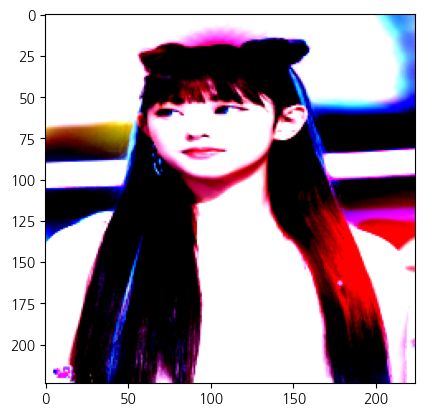

In [7]:
plt.imshow(img.permute(1,2,0))      # 차원의 순서를 바꿔줌.

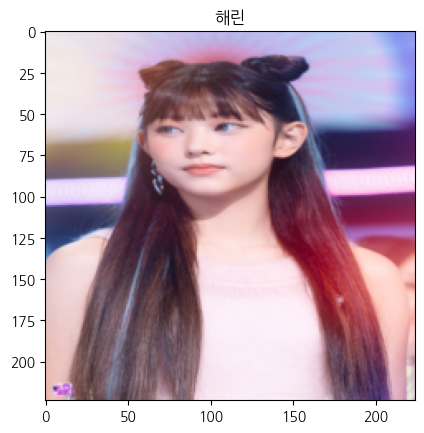

In [8]:
# 이미지 편하게 보는 함수

def img_show(img, title):
    mean = torch.tensor([0.485,0.456,0.406])
    std = torch.tensor([0.229,0.224,0.225])
    img_perm = img.permute(1,2,0)
    img_orig = img_perm * std + mean              # 역정규화로 이미지 복원
    plt.title(title)
    plt.imshow(img_orig)
    plt.show()

img_show(img, "해린")

In [9]:
batch_size = 16

train_loader = torch.utils.data.DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_loader = torch.utils.data.DataLoader(test_dataset, shuffle=False, batch_size=batch_size)

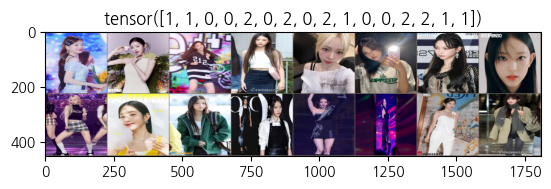

In [10]:
imgs, labels = next(iter(train_loader))
out_imgs = torchvision.utils.make_grid(imgs)        # 데이터 확인할 때 쓰는 코드

img_show(out_imgs, labels)

In [12]:
model = models.resnet34(pretrained=True)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [13]:
# 학습할 가중치를 확인하기.
for name, module in model.named_parameters():
    print(name, module.requires_grad)

conv1.weight True
bn1.weight True
bn1.bias True
layer1.0.conv1.weight True
layer1.0.bn1.weight True
layer1.0.bn1.bias True
layer1.0.conv2.weight True
layer1.0.bn2.weight True
layer1.0.bn2.bias True
layer1.1.conv1.weight True
layer1.1.bn1.weight True
layer1.1.bn1.bias True
layer1.1.conv2.weight True
layer1.1.bn2.weight True
layer1.1.bn2.bias True
layer1.2.conv1.weight True
layer1.2.bn1.weight True
layer1.2.bn1.bias True
layer1.2.conv2.weight True
layer1.2.bn2.weight True
layer1.2.bn2.bias True
layer2.0.conv1.weight True
layer2.0.bn1.weight True
layer2.0.bn1.bias True
layer2.0.conv2.weight True
layer2.0.bn2.weight True
layer2.0.bn2.bias True
layer2.0.downsample.0.weight True
layer2.0.downsample.1.weight True
layer2.0.downsample.1.bias True
layer2.1.conv1.weight True
layer2.1.bn1.weight True
layer2.1.bn1.bias True
layer2.1.conv2.weight True
layer2.1.bn2.weight True
layer2.1.bn2.bias True
layer2.2.conv1.weight True
layer2.2.bn1.weight True
layer2.2.bn1.bias True
layer2.2.conv2.weight True


In [14]:
# 가중치 얼리기
for param in model.parameters():
    param.requires_grad = False

In [15]:
# 마지막 레이어인 분류기 바꿔주기 (class = 3)
model.fc = nn.Linear(512, 3)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [16]:
num_epochs = 10
lr = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [75]:
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [78]:
for ep in range(num_epochs):
    
    running_loss = 0.0
    
    loop = tqdm(train_loader, leave=True)
    for img, labels in loop:
        optimizer.zero_grad()
        
        preds = model(img.to(device))
        loss = criterion(preds, labels.to(device))
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    print(f"epoch: {ep+1}\tmean loss: {running_loss/len(train_loader):.4f}")

100%|██████████| 15/15 [00:07<00:00,  2.06it/s]


epoch: 1	mean loss: 0.9611


100%|██████████| 15/15 [00:07<00:00,  1.98it/s]


epoch: 2	mean loss: 0.9448


100%|██████████| 15/15 [00:07<00:00,  2.01it/s]


...

epoch: 8	mean loss: 0.9016


100%|██████████| 15/15 [00:07<00:00,  1.96it/s]


epoch: 9	mean loss: 0.8741


100%|██████████| 15/15 [00:07<00:00,  1.90it/s]

epoch: 10	mean loss: 0.8902


tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


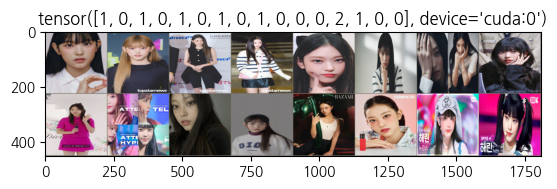

tensor([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


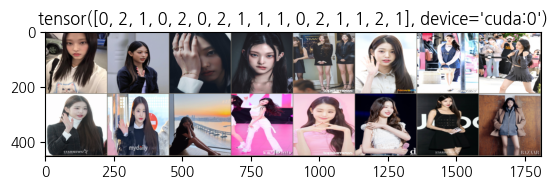

tensor([1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2])


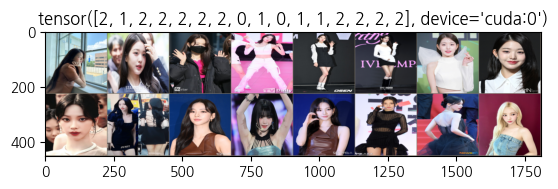

tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])


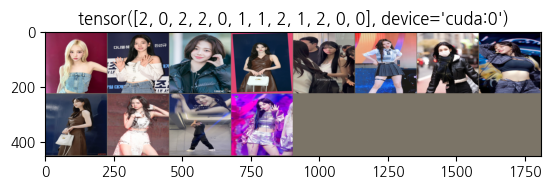

Acc: 45.0


In [85]:
model.eval()
with torch.no_grad():
    corrects = 0
    
    for imgs, labels in test_loader:
        preds = model(imgs.to(device))
        pred = torch.max(preds,1)[1]

        corrects += (pred==labels.to(device)).sum()
        img_grid = torchvision.utils.make_grid(imgs)
        print(labels)
        img_show(img_grid.cpu(), title=pred)
    
    acc = corrects / len(test_dataset.targets) * 100
    
    print(f"Acc: {acc}")

# Fine-Tuning
* 데이터셋이 적다면 high-level representation을 미세조정해본다.

In [98]:
### 제대로된 실험을 위해 model을 다시 초기화한다. ###
model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

# 분류기 바꿔주기
model.fc = nn.Linear(512,3)

In [99]:
# 학습할 가중치를 확인하기.
for name, module in model.named_parameters():
    print(name, module.requires_grad)

conv1.weight True
bn1.weight True
bn1.bias True
layer1.0.conv1.weight True
layer1.0.bn1.weight True
layer1.0.bn1.bias True
layer1.0.conv2.weight True
layer1.0.bn2.weight True
layer1.0.bn2.bias True
layer1.1.conv1.weight True
layer1.1.bn1.weight True
layer1.1.bn1.bias True
layer1.1.conv2.weight True
layer1.1.bn2.weight True
layer1.1.bn2.bias True
layer1.2.conv1.weight True
layer1.2.bn1.weight True
layer1.2.bn1.bias True
layer1.2.conv2.weight True
layer1.2.bn2.weight True
layer1.2.bn2.bias True
layer2.0.conv1.weight True
layer2.0.bn1.weight True
layer2.0.bn1.bias True
layer2.0.conv2.weight True
layer2.0.bn2.weight True
layer2.0.bn2.bias True
layer2.0.downsample.0.weight True
layer2.0.downsample.1.weight True
layer2.0.downsample.1.bias True
layer2.1.conv1.weight True
layer2.1.bn1.weight True
layer2.1.bn1.bias True
layer2.1.conv2.weight True
layer2.1.bn2.weight True
layer2.1.bn2.bias True
layer2.2.conv1.weight True
layer2.2.bn1.weight True
layer2.2.bn1.bias True
layer2.2.conv2.weight True


In [100]:
# 전체 가중치 얼리기
for param in model.parameters():
    param.requires_grad = False

# 분류기 unfreeze하기
for param in model.fc.parameters():
    param.requires_grad = True

# 마지막 단인 layer3 unfreeze하기
for param in model.layer3.parameters():
    param.requires_grad = True

# 마지막 단인 layer4 unfreeze하기
for param in model.layer4.parameters():
    param.requires_grad = True



In [101]:
# 원하는 레이어만 켜졌는지 확인하기

trainable = [n for n,p in model.named_parameters() if p.requires_grad]
print("\n".join(trainable))

layer3.0.conv1.weight
layer3.0.bn1.weight
layer3.0.bn1.bias
layer3.0.conv2.weight
layer3.0.bn2.weight
layer3.0.bn2.bias
layer3.0.downsample.0.weight
layer3.0.downsample.1.weight
layer3.0.downsample.1.bias
layer3.1.conv1.weight
layer3.1.bn1.weight
layer3.1.bn1.bias
layer3.1.conv2.weight
layer3.1.bn2.weight
layer3.1.bn2.bias
layer3.2.conv1.weight
layer3.2.bn1.weight
layer3.2.bn1.bias
layer3.2.conv2.weight
layer3.2.bn2.weight
layer3.2.bn2.bias
layer3.3.conv1.weight
layer3.3.bn1.weight
layer3.3.bn1.bias
layer3.3.conv2.weight
layer3.3.bn2.weight
layer3.3.bn2.bias
layer3.4.conv1.weight
layer3.4.bn1.weight
layer3.4.bn1.bias
layer3.4.conv2.weight
layer3.4.bn2.weight
layer3.4.bn2.bias
layer3.5.conv1.weight
layer3.5.bn1.weight
layer3.5.bn1.bias
layer3.5.conv2.weight
layer3.5.bn2.weight
layer3.5.bn2.bias
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsamp

In [102]:
for name, grad in model.named_parameters():
    print(name, grad.requires_grad)

conv1.weight False
bn1.weight False
bn1.bias False
layer1.0.conv1.weight False
layer1.0.bn1.weight False
layer1.0.bn1.bias False
layer1.0.conv2.weight False
layer1.0.bn2.weight False
layer1.0.bn2.bias False
layer1.1.conv1.weight False
layer1.1.bn1.weight False
layer1.1.bn1.bias False
layer1.1.conv2.weight False
layer1.1.bn2.weight False
layer1.1.bn2.bias False
layer1.2.conv1.weight False
layer1.2.bn1.weight False
layer1.2.bn1.bias False
layer1.2.conv2.weight False
layer1.2.bn2.weight False
layer1.2.bn2.bias False
layer2.0.conv1.weight False
layer2.0.bn1.weight False
layer2.0.bn1.bias False
layer2.0.conv2.weight False
layer2.0.bn2.weight False
layer2.0.bn2.bias False
layer2.0.downsample.0.weight False
layer2.0.downsample.1.weight False
layer2.0.downsample.1.bias False
layer2.1.conv1.weight False
layer2.1.bn1.weight False
layer2.1.bn1.bias False
layer2.1.conv2.weight False
layer2.1.bn2.weight False
layer2.1.bn2.bias False
layer2.2.conv1.weight False
layer2.2.bn1.weight False
layer2.2.bn1

In [103]:
num_epochs = 10
lr = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizer = optim.Adam([
    {"params": model.layer4.parameters(), "lr": lr},
    {"params": model.fc.parameters(),     "lr": 1e-5},
])
criterion = nn.CrossEntropyLoss()
model.to(device)

model.train()

for ep in range(num_epochs):
    
    running_loss = 0.0
    
    loop = tqdm(train_loader, leave=True)
    for img, labels in loop:
        
        optimizer.zero_grad()
        preds = model(img.to(device))
        loss = criterion(preds, labels.to(device))
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        loop.set_description(f"Epoch [{ep+1}/{num_epochs}]")
        loop.set_postfix(loss=loss.item())
        
    print(f"epoch: {ep+1}\tmean loss: {running_loss/len(train_loader):.4f}")

Epoch [1/10]: 100%|██████████| 15/15 [00:07<00:00,  1.93it/s, loss=0.705]


epoch: 1	mean loss: 1.0681


Epoch [2/10]: 100%|██████████| 15/15 [00:08<00:00,  1.87it/s, loss=0.423]


epoch: 2	mean loss: 0.3564


Epoch [3/10]: 100%|██████████| 15/15 [00:07<00:00,  1.97it/s, loss=0.0917]


...

epoch: 8	mean loss: 0.0202


Epoch [9/10]: 100%|██████████| 15/15 [00:07<00:00,  1.99it/s, loss=0.0083] 


epoch: 9	mean loss: 0.0079


Epoch [10/10]: 100%|██████████| 15/15 [00:07<00:00,  1.89it/s, loss=0.00537]

epoch: 10	mean loss: 0.0075


tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


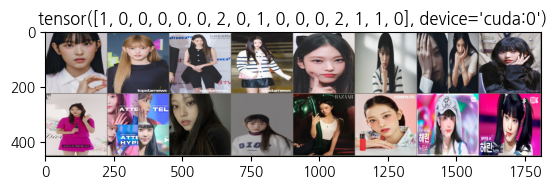

tensor([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


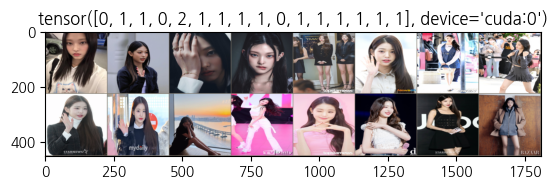

tensor([1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2])


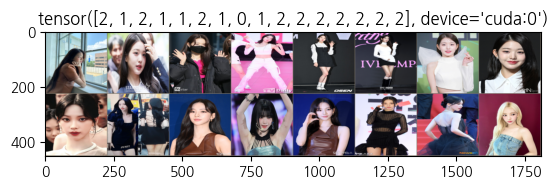

tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])


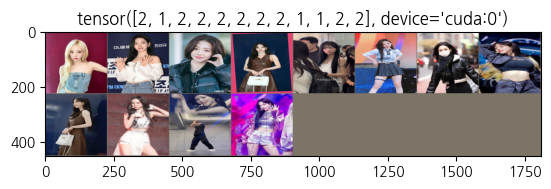

Acc: 70.00000762939453


In [105]:
model.eval()
with torch.no_grad():
    corrects = 0
    
    for imgs, labels in test_loader:
        preds = model(imgs.to(device))
        pred = torch.max(preds,1)[1]

        corrects += (pred==labels.to(device)).sum()
        img_grid = torchvision.utils.make_grid(imgs)
        print(labels)
        img_show(img_grid.cpu(), title=pred)
    
    acc = corrects / len(test_dataset.targets) * 100
    
    print(f"Acc: {acc}")

In [ ]:
# model 가중치만 저장하는 방법 1 - 가장 권장되고 많이 쓰임.
#torch.save(model.state_dict(), "./models/celeb_resnet34.pth")

# Grad-CAM
* "First-order Taylor approximation 기반"

In [67]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [68]:
model = models.resnet34()
model.fc = nn.Linear(model.fc.in_features, 3)

model.load_state_dict(torch.load("./models/celeb_resnet34.pth"))

<All keys matched successfully>

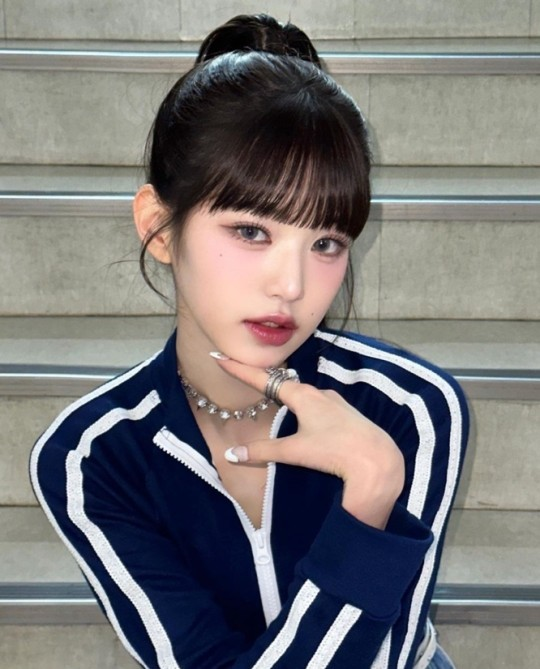

In [69]:
model.eval()
model.to(device)
img = Image.open("./data/Celeb/train/장원영/Image_80.jpg").convert("RGB")

img

In [70]:
input_tensor = transform_test(img).unsqueeze(0).to(device)

for param in model.parameters():
    param.requires_grad = True

pred = model(input_tensor)
pred_class = pred.argmax().item()
pred_class

1

In [86]:
## grad_CAM으로 가장 많이 쓰이는 feature map layer는 가장 마지막단 또는 그 전 layer의 블록을 사용한다.
target_layers = [model.layer4[-1]]
target_layers

[BasicBlock(
   (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
   (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (relu): ReLU(inplace=True)
   (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
   (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 )]

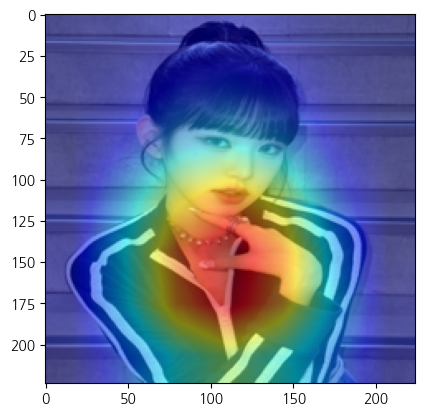

In [87]:
cam = GradCAM(model=model, target_layers=target_layers)
grad_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(pred_class)])[0]

rgb_img = np.array(img.resize((224,224))).astype(np.float32)/255.0      # 255로 나눠서 정규화

visualization = show_cam_on_image(rgb_img, grad_cam, use_rgb=True)

plt.imshow(visualization)
plt.show()

# Grad-CAM++
* "Higher-order derivative를 사용한 더 정밀한 attribution"

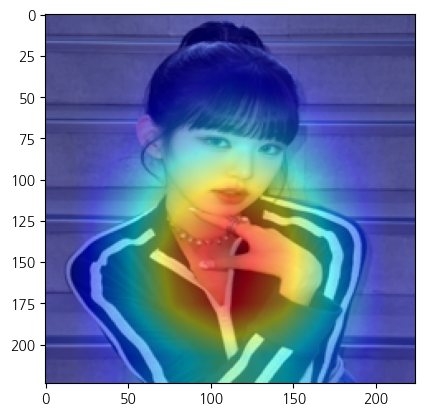

In [92]:
from pytorch_grad_cam import GradCAMPlusPlus

cam = GradCAMPlusPlus(model=model, target_layers=target_layers)

ppcam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(pred_class)])[0]

rgb_img = np.array(img.resize((224,224))).astype(np.float32)/255.0      # 255로 나눠서 정규화

visualization = show_cam_on_image(rgb_img, ppcam, use_rgb=True)

plt.imshow(visualization)
plt.show()

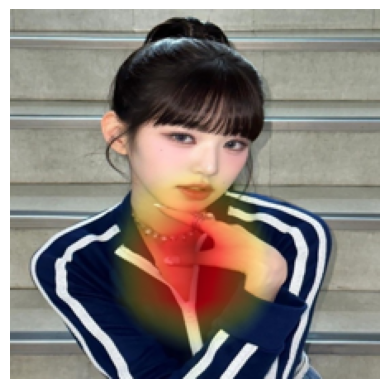

In [95]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# rgb_img: (H,W,3) float [0,1]
# grad_cam: (H,W) float [0,1]

H, W = grad_cam.shape

# 1) CAM을 컬러 heatmap으로 만들기 (원본과 섞지 말고 heatmap만)
heatmap_u8 = np.uint8(255 * grad_cam)
heatmap = cv2.applyColorMap(heatmap_u8, cv2.COLORMAP_JET)      # (H,W,3) BGR uint8
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0  # RGB float [0,1]

# 2) "파란 부분 제거" = alpha를 activation으로 만들기
#   - threshold 방식 (가장 직관적)
t = 0.5  # 0.5~0.8 사이 조절
alpha = np.clip((grad_cam - t) / (1.0 - t + 1e-8), 0, 1)       # t 이하는 0(투명), 높을수록 1
alpha = alpha[..., None]                                      # (H,W,1)

# 3) 원본은 그대로 두고, heatmap만 alpha로 블렌딩
overlay_strength = 0.8  # 히트맵 진하게(0~1)
out = rgb_img * (1 - alpha * overlay_strength) + heatmap * (alpha * overlay_strength)
out = np.clip(out, 0, 1)

plt.imshow(out)
plt.axis("off")
plt.show()